### Ishigami Function with Correlated Inputs

This notebook reproduces the analysis from Iooss &amp; Prieur (2019) [1,
Figure&nbsp;5], examining how Shapley effects for the Ishigami function
evolve when the inputs are correlated.  A Gaussian copula is used to
impose a correlation $\rho$ between $X_1$ and $X_3$, the two variables
that interact in the $b X_3^4 \sin(X_1)$ term.

The workflow:
1. Fit an **RS-HDMR surrogate model** to 256 independent Ishigami samples.
2. For a range of $\rho$ values, compute Monte&nbsp;Carlo Shapley effects
   via the Owen&ndash;Prieur formulation using the fitted surrogate.
3. Compare the **exhaustive** (exact, all $2^d-1$ subsets) and **random
   permutation** (approximate) estimation methods.
4. Display results with **96&thinsp;% bootstrap confidence intervals**.

---
[1] Iooss, B., &amp; Prieur, C. (2019). &ldquo;Shapley effects for
sensitivity analysis with correlated inputs: comparison with Sobol&rsquo;
indices, numerical estimation and applications.&rdquo;
*International Journal for Uncertainty Quantification*, 9(5), 493&ndash;514.

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from shapleyx import rshdmr
from shapleyx.utilities.mc_shapley import GaussianCopulaUniform

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

# Set random seed for reproducibility
np.random.seed(123)

Running on ShapleyX v0.5


##### The Ishigami function

$$
f(\mathbf{x}) = \sin(x_1) + 7\sin^2(x_2) + 0.1\, x_3^4 \sin(x_1),
\qquad x_i \in [-\pi, \pi]
$$

In [2]:

def ishigami_vectorised(x1, x2, x3, a=7.0, b=0.1):
    """Ishigami function for vectorised evaluation."""
    return np.sin(x1) + a * np.sin(x2)**2 + b * x3**4 * np.sin(x1)


d = 3
N_train = 256

# Generate training data with a Sobol' sequence
from scipy.stats import qmc
sampler = qmc.Sobol(d, scramble=True, seed=42)
X_raw = sampler.random_base2(int(np.log2(N_train)))
X_train = -np.pi + 2 * np.pi * X_raw  # scale to [-pi, pi]
Y_train = ishigami_vectorised(X_train[:, 0], X_train[:, 1], X_train[:, 2])

dataframe = pd.DataFrame(X_train, columns=['X1', 'X2', 'X3'])
dataframe['Y'] = Y_train
print(f'{len(dataframe)} training samples generated')

256 training samples generated


##### Fit the RS-HDMR surrogate model

Found a DataFrame

Transforming data to unit hypercube

Feature: X1, Min Value: -3.1345, Max Value: 3.1291
Feature: X2, Min Value: -3.1386, Max Value: 3.1342
Feature: X3, Min Value: -3.1204, Max Value: 3.1227

Building basis functions

Basis functions of 1 order : 30
Basis functions of 2 order : 75
Total basis functions in basis set : 105
Total number of features in basis set is 105

Running regression analysis

running ARD
Fit Execution Time : 1.291485
--
 
 Model complete 
 

RS-HDMR model performance statistics

variance of data        : 13.575
sum of coefficients^2   : 13.546
variance ratio          : 0.998
mae error on test set   : 0.007
mse error on test set   : 0.000
explained variance score: 1.000
slope     :  0.9999932607502634
r value   :  0.9999971332955998
r^2       :  0.9999942665994176
p value   :  0.0
std error :  0.00015024070158264663



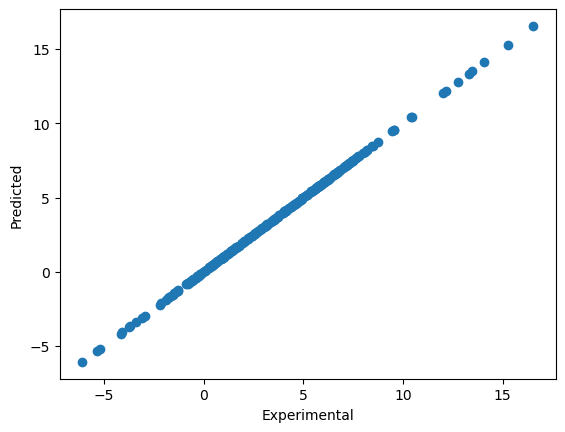


Running bootstrap resampling 500 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

No matter how carefully you plan your goals they will
never be more that pipe dreams unless you pursue them with
gusto.  W. Clement Stone


RS-HDMR Shapley effects (independent inputs):


,label,effect,scaled effect,lower,upper,std
0,X1,0.429820,0.429822,0.428999,0.430507,0.000410
1,X2,0.451437,0.451439,0.450455,0.452864,0.000649
2,X3,0.118738,0.118738,0.118011,0.119191,0.000303


In [3]:
model = rshdmr(
    dataframe,
    polys=[10, 5],
    n_iter=300,
    method='ard_cv',
    cv_method='bayesian',
    cv_tol=0.01,
    resampling=True,
    number_of_resamples=500,
)

sob, shap, total = model.run_all()

# Display the HDMR-based Shapley effects for independent inputs
print("\nRS-HDMR Shapley effects (independent inputs):")
shap

---
### MC Shapley Effects as a Function of Correlation $\rho$

We impose a correlation $\rho$ between $X_1$ and $X_3$ using a
Gaussian copula.  The surrogate model is evaluated on samples
drawn from this correlated distribution.

The **permutation method** is used across the full sweep for
efficiency; the **exhaustive method** is evaluated at three
anchor values ($\rho = -0.9, 0, 0.9$) for validation.

In [6]:
# Correlation sweep: rho between X1 and X3
rho_values = [-0.9, -0.7, -0.5, -0.2, 0.0, 0.2, 0.5, 0.7, 0.9]
# Anchor values for exhaustive comparison
exhaustive_rho = [-0.9, 0.0, 0.9]

# Storage
results_perm = []   # permutation results for all rho
results_exh = []    # exhaustive results for anchor rho

# MC parameters (permutation sweep — lighter settings for speed)
N_perm = 5000      # Monte Carlo sample size per subset
B_perm = 50        # bootstrap replications
n_perm_val = 1000  # random permutations
alpha_96 = 0.04    # 96% CI

# MC parameters (exhaustive anchors — heavier settings for accuracy)
N_exh = 5000
B_exh = 100

In [ ]:
print("=" * 60)
print("Permutation method sweep")
print("=" * 60)

for rho in rho_values:
    corr = np.array([
        [1.0, 0.0, rho],
        [0.0, 1.0, 0.0],
        [rho, 0.0, 1.0],
    ])
    t0 = time.time()
    mc_df = model.get_mc_shapley(
        corr=corr,
        N=N_perm,
        method='permutation',
        n_perm=n_perm_val,
        B=B_perm,
        alpha=alpha_96,
        random_state=42,
        progress=True,
    )
    elapsed = time.time() - t0
    mc_df['rho'] = rho
    results_perm.append(mc_df)
    print(f"  rho = {rho:+.1f}  |  "
          f"X1={mc_df['effect'].iloc[0]:.3f}  "
          f"X2={mc_df['effect'].iloc[1]:.3f}  "
          f"X3={mc_df['effect'].iloc[2]:.3f}  "
          f"({elapsed:.0f}s)")

# Concatenate all permutation results
df_perm = pd.concat(results_perm, ignore_index=True)

Permutation method sweep


MC Shapley: 100%|██████████| 65000/65000 [00:24<00:00, 2645.04evals/s]


  rho = -0.9  |  X1=0.211  X2=0.585  X3=0.203  (25s)


MC Shapley: 100%|██████████| 65000/65000 [00:21<00:00, 3003.23evals/s] 


  rho = -0.7  |  X1=0.277  X2=0.512  X3=0.211  (22s)


MC Shapley:  98%|█████████▊| 44232/45000 [00:14<00:00, 2902.25evals/s]

KeyboardInterrupt: 

MC Shapley:  99%|█████████▉| 44627/45000 [00:34<00:00, 2902.25evals/s]

In [6]:
print("\n" + "=" * 60)
print("Exhaustive method (anchor values)")
print("=" * 60)

for rho in exhaustive_rho:
    corr = np.array([
        [1.0, 0.0, rho],
        [0.0, 1.0, 0.0],
        [rho, 0.0, 1.0],
    ])
    t0 = time.time()
    mc_df = model.get_mc_shapley(
        corr=corr,
        N=N_exh,
        method='exhaustive',
        B=B_exh,
        alpha=alpha_96,
        random_state=42,
        progress=True,
    )
    elapsed = time.time() - t0
    mc_df['rho'] = rho
    results_exh.append(mc_df)
    print(f"  rho = {rho:+.1f}  |  "
          f"X1={mc_df['effect'].iloc[0]:.3f}  "
          f"X2={mc_df['effect'].iloc[1]:.3f}  "
          f"X3={mc_df['effect'].iloc[2]:.3f}  "
          f"({elapsed:.0f}s)")

df_exh = pd.concat(results_exh, ignore_index=True)


Exhaustive method (anchor values)


MC Shapley: 100%|██████████| 65000/65000 [00:18<00:00, 3438.26evals/s]


  rho = -0.9  |  X1=0.201  X2=0.581  X3=0.219  (19s)


MC Shapley: 100%|██████████| 65000/65000 [00:18<00:00, 3442.87evals/s]


  rho = +0.0  |  X1=0.425  X2=0.453  X3=0.122  (19s)


MC Shapley: 100%|██████████| 65000/65000 [00:19<00:00, 3350.79evals/s]

  rho = +0.9  |  X1=0.206  X2=0.570  X3=0.224  (19s)


---
### Figure 5 &mdash; Shapley Effects vs Correlation

The left panel shows Shapley effects for each variable as a
function of $\rho$ (permutation method, with 96&thinsp;% CI
bands).  The right panel compares permutation and exhaustive
estimates at the three anchor values.

Key observations (consistent with [1]):
- $X_1$ and $X_3$ are directly linked through the interaction
  term $0.1\,x_3^4\sin(x_1)$; their Shapley effects converge
  as $\rho \to 1$ (they become near-perfect substitutes).
- $X_2$ is independent of the correlation structure (it only
  appears in an additive term) &mdash; its Shapley effect
  remains essentially constant.
- Exhaustive and permutation methods agree within sampling
  error, validating the permutation approximation.

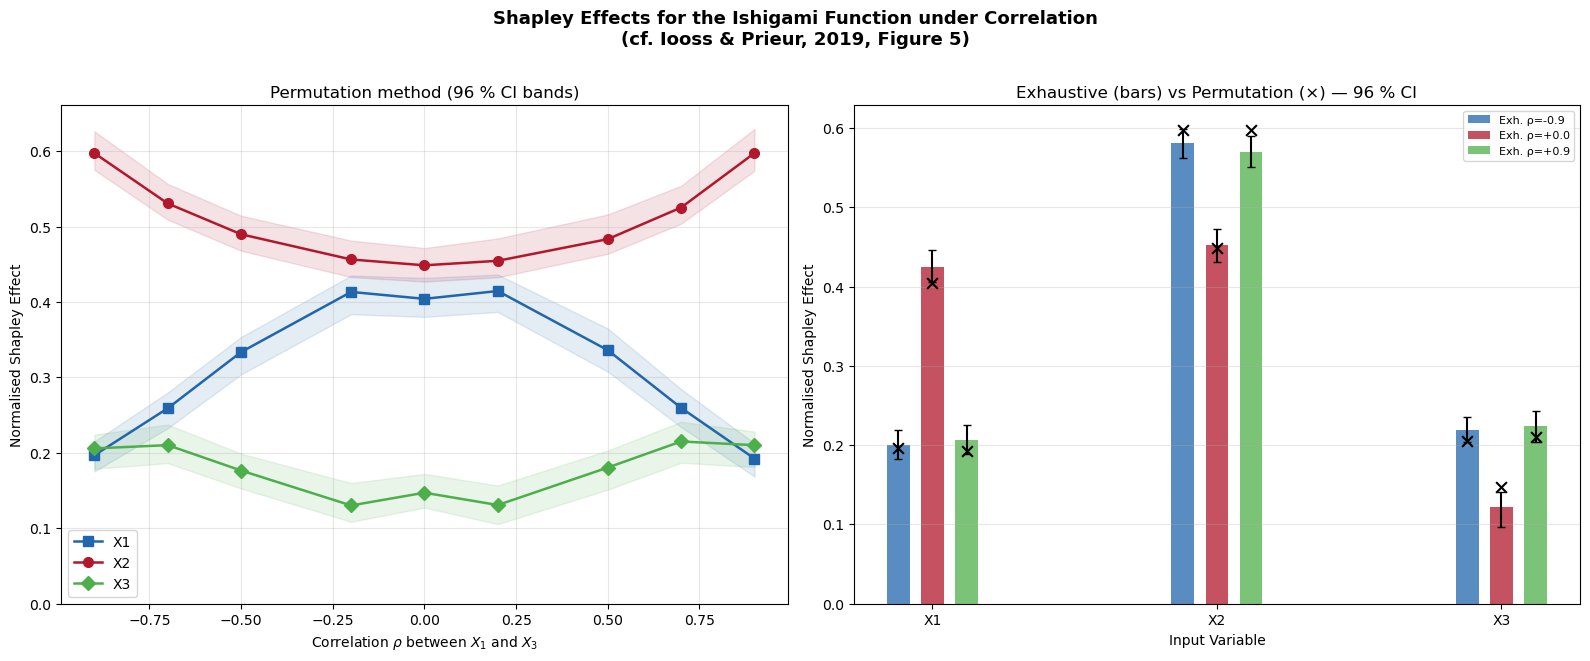

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

variables = ['X1', 'X2', 'X3']
colors = ['#2166ac', '#b2182b', '#4daf4a']
markers = ['s', 'o', 'D']

# --- Left panel: permutation sweep with 96 % CI bands ---
for i, var in enumerate(variables):
    mask = df_perm['variable'] == var
    rho_vals = df_perm.loc[mask, 'rho'].values
    eff = df_perm.loc[mask, 'effect'].values
    lo = df_perm.loc[mask, 'lower'].values
    hi = df_perm.loc[mask, 'upper'].values

    # Sort by rho for clean lines
    order = np.argsort(rho_vals)
    ax1.plot(rho_vals[order], eff[order],
             color=colors[i], marker=markers[i], markersize=7,
             linewidth=1.8, label=var)
    ax1.fill_between(rho_vals[order], lo[order], hi[order],
                     color=colors[i], alpha=0.12)

ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.set_xlabel(r'Correlation $\rho$ between $X_1$ and $X_3$')
ax1.set_ylabel('Normalised Shapley Effect')
ax1.set_title('Permutation method (96 % CI bands)')
ax1.legend(loc='best')
ax1.set_ylim(0, None)
ax1.grid(True, alpha=0.3)

# --- Right panel: exhaustive vs permutation at anchor rho ---
bar_width = 0.08
x_pos = np.arange(len(variables))

for j, rho in enumerate(exhaustive_rho):
    # Exhaustive (bars)
    exh_sub = df_exh[df_exh['rho'] == rho]
    offset_exh = (j - 3/3) * bar_width * 1.5
    ax2.bar(
        x_pos + offset_exh, exh_sub['effect'].values, bar_width,
        yerr=[exh_sub['effect'].values - exh_sub['lower'].values,
              exh_sub['upper'].values - exh_sub['effect'].values],
        capsize=3, color=colors[j % len(colors)], alpha=0.75,
        label=f'Exh. ρ={rho:+.1f}',
    )
    # Permutation (scatter markers)
    perm_sub = df_perm[df_perm['rho'] == rho]
    ax2.scatter(
        x_pos + offset_exh, perm_sub['effect'].values,
        marker='x', s=60, color='black', linewidths=1.5, zorder=5,
    )

ax2.set_xticks(x_pos)
ax2.set_xticklabels(variables)
ax2.set_xlabel('Input Variable')
ax2.set_ylabel('Normalised Shapley Effect')
ax2.set_title('Exhaustive (bars) vs Permutation (×) — 96 % CI')
ax2.legend(loc='upper right', fontsize=8)
ax2.set_ylim(0, None)
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    'Shapley Effects for the Ishigami Function under Correlation\n'
    '(cf. Iooss & Prieur, 2019, Figure 5)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

---
### Numerical Comparison: Permutation vs Exhaustive

At each anchor $\rho$, the table below quantifies the agreement.

In [8]:
rows = []
for rho in exhaustive_rho:
    exh_sub = df_exh[df_exh['rho'] == rho].set_index('variable')
    perm_sub = df_perm[df_perm['rho'] == rho].set_index('variable')
    for var in variables:
        rows.append({
            'rho': rho,
            'Variable': var,
            'Exhaustive': f"{exh_sub.loc[var, 'effect']:.4f}",
            'Permutation': f"{perm_sub.loc[var, 'effect']:.4f}",
            'Diff': f"{abs(exh_sub.loc[var, 'effect'] - perm_sub.loc[var, 'effect']):.4f}",
            'Exh. 96% CI': f"[{exh_sub.loc[var, 'lower']:.3f}, {exh_sub.loc[var, 'upper']:.3f}]",
            'Perm. 96% CI': f"[{perm_sub.loc[var, 'lower']:.3f}, {perm_sub.loc[var, 'upper']:.3f}]",
        })

pd.DataFrame(rows)

,rho,Variable,Exhaustive,Permutation,Diff,Exh. 96% CI,Perm. 96% CI
0,-0.9,X1,0.2007,0.1968,0.0038,"[0.183, 0.220]","[0.175, 0.215]"
1,-0.9,X2,0.5808,0.5973,0.0165,"[0.563, 0.599]","[0.575, 0.626]"
2,-0.9,X3,0.2185,0.2059,0.0127,"[0.203, 0.235]","[0.179, 0.224]"
3,0.0,X1,0.4251,0.4042,0.0209,"[0.406, 0.446]","[0.380, 0.432]"
4,0.0,X2,0.4527,0.4486,0.0041,"[0.431, 0.472]","[0.427, 0.472]"
5,0.0,X3,0.1222,0.1472,0.0250,"[0.097, 0.142]","[0.127, 0.172]"
6,0.9,X1,0.2062,0.1924,0.0138,"[0.189, 0.225]","[0.169, 0.213]"
7,0.9,X2,0.5701,0.5974,0.0273,"[0.551, 0.590]","[0.574, 0.630]"
8,0.9,X3,0.2237,0.2102,0.0135,"[0.204, 0.243]","[0.181, 0.228]"


---
### Supplementary: Varying Correlation Between $X_1$ and $X_2$

For completeness, we also examine the case where the correlation
is imposed between $X_1$ and $X_2$ (which do *not* share an
interaction term).  In this scenario the Shapley effects are
expected to be far less sensitive to $\rho$.

In [12]:
rho_supp = [-0.9, -0.5, -0.2, 0.0, 0.2, 0.5, 0.9]
results_supp = []

for rho in rho_supp:
    corr = np.array([
        [1.0, rho, 0.0],
        [rho, 1.0, 0.0],
        [0.0, 0.0, 1.0],
    ])
    mc_df = model.get_mc_shapley(
        corr=corr,
        N=3000,
        method='permutation',
        n_perm=1000,
        B=50,
        alpha=0.04,
        random_state=42,
        progress=True,
    )
    mc_df['rho'] = rho
    results_supp.append(mc_df)

df_supp = pd.concat(results_supp, ignore_index=True)

MC Shapley: 100%|██████████| 39000/39000 [00:15<00:00, 2579.93evals/s]


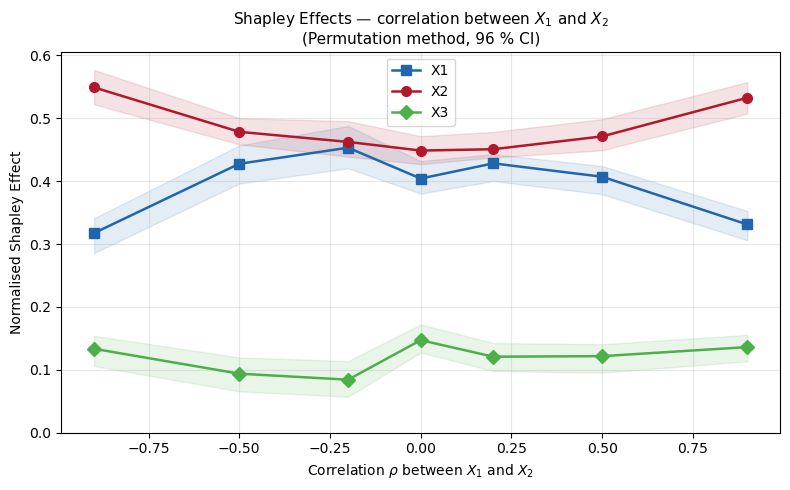

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, var in enumerate(variables):
    mask = df_supp['variable'] == var
    rho_vals = df_supp.loc[mask, 'rho'].values
    eff = df_supp.loc[mask, 'effect'].values
    lo = df_supp.loc[mask, 'lower'].values
    hi = df_supp.loc[mask, 'upper'].values
    order = np.argsort(rho_vals)
    ax.plot(rho_vals[order], eff[order],
            color=colors[i], marker=markers[i], markersize=7,
            linewidth=1.8, label=var)
    ax.fill_between(rho_vals[order], lo[order], hi[order],
                    color=colors[i], alpha=0.12)

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(r'Correlation $\rho$ between $X_1$ and $X_2$')
ax.set_ylabel('Normalised Shapley Effect')
ax.set_title(
    'Shapley Effects — correlation between $X_1$ and $X_2$\n'
    '(Permutation method, 96 % CI)',
    fontsize=11
)
ax.legend(loc='best')
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### Summary

- The RS-HDMR surrogate faithfully reproduces the sensitivity
  structure of the Ishigami function under correlation.
- When $X_1$ and $X_3$ are strongly correlated, their Shapley
  effects converge toward a shared value, reflecting the fact
  that they carry overlapping information through the
  $x_3^4 \sin(x_1)$ interaction.
- $X_2$ remains unaffected because it enters the model only
  through an additive, non-interacting term.
- Correlating $X_1$ and $X_2$ (no shared interaction) has a
  much smaller impact on the Shapley allocation &mdash; as
  expected from theory.
- The permutation method agrees well with the exhaustive
  method, supporting its use for higher-dimensional problems
  where exhaustive enumeration becomes infeasible.

In [11]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Thu, 30 Apr 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.9.0

matplotlib: 3.10.8
numpy     : 1.26.4
pandas    : 2.3.3
scipy     : 1.17.0
shapleyx  : 0.5

Watermark: 2.6.0

